## 1. Imports

In [1]:
%matplotlib inline
import csv
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
from scipy.stats import ttest_ind
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from collections import defaultdict
from matplotlib.lines import Line2D
import torch
import torch.nn as nn
import torch.nn.functional as F
import dgl
from dgl.nn import SAGEConv, GATConv, GraphConv
from dgl.nn.pytorch import GINConv, ChebConv, TAGConv

## 2. Settings
Set the model and network here, then run the notebook top to bottom. The default is `ATTAG` on `ggnet` (the 32×4 embedding JSON in `data/`). Everything the pipeline writes goes to `results/gene_prediction/`.

In [2]:
import random
from argparse import Namespace
from pathlib import Path

# Seed model initialization and training for reproducibility.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
try:
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
except Exception:
    pass

args = Namespace(
    in_feats=128,
    hidden_feats=128,
    out_feats=1,
    learning_rate=0.001,
    num_epochs=200,
    model_type="ATTAG",      # GraphSAGE, GAT, HGDC, EMOGI, MTGCN, GCN, GIN, Chebnet, PERTAG, ATTAG
    net_type="ggnet",        # ggnet, ppnet, pathnet
    device="cuda" if torch.cuda.is_available() else "cpu",
    score_threshold=0.85,
)

# Resolve the project directory whether Jupyter starts in the repository root or ATTAG/.
expected_data = Path("data") / f"{args.net_type}_omics_filtered_combined_gene_embeddings_32x4.json"
if not expected_data.exists() and (Path("ATTAG") / expected_data).exists():
    os.chdir(Path("ATTAG"))

os.makedirs("results/gene_prediction", exist_ok=True)
print("Working directory:", Path.cwd())
print(args)

Working directory: /Users/ericsali/Documents/2024_Winter/Project_gnn/reactome_markers/gnn_pathways/ATTAG
Namespace(in_feats=128, hidden_feats=128, out_feats=1, learning_rate=0.001, num_epochs=200, model_type='ATTAG', net_type='ggnet', device='cpu', score_threshold=0.85)


## 3. Models
Focal loss, the baseline GNNs (`GraphSAGE`, `GAT`, `GCN`, `GIN`, `Chebnet`), and the TAG-based models (`PERTAG`: TAGConv with residuals; `ATTAG`: TAGConv with a node-attention layer). `choose_model` maps `model_type` to a model; `HGDC` and `EMOGI` run the `GAT` model and `MTGCN` runs `GCN`, as in the original script.

In [3]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ##bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        # Ensure targets are of type float
        targets = targets.float()

        # Compute BCE loss
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')

        probas = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probas, 1 - probas)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

In [4]:
class Chebnet(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, k=3):
        """
        Chebnet implementation using DGL's ChebConv.
        
        Parameters:
        - in_feats: Number of input features.
        - hidden_feats: Number of hidden layer features.
        - out_feats: Number of output features.
        - k: Chebyshev polynomial order.
        """
        super(Chebnet, self).__init__()
        self.cheb1 = ChebConv(in_feats, hidden_feats, k)
        self.cheb2 = ChebConv(hidden_feats, hidden_feats, k)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

    def forward(self, g, features):
        """
        Forward pass for Chebnet.
        
        Parameters:
        - g: DGL graph.
        - features: Input features tensor.
        
        Returns:
        - Output tensor after passing through Chebnet layers.
        """
        x = F.relu(self.cheb1(g, features))
        x = F.relu(self.cheb2(g, x))
        return self.mlp(x)


class GIN(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats):
        super(GIN, self).__init__()
        # Define the first GIN layer
        self.gin1 = GINConv(
            nn.Sequential(
                nn.Linear(in_feats, hidden_feats),
                nn.ReLU(),
                nn.Linear(hidden_feats, hidden_feats)
            ),
            'mean'  # Aggregation method: 'mean', 'max', or 'sum'
        )
        # Define the second GIN layer
        self.gin2 = GINConv(
            nn.Sequential(
                nn.Linear(hidden_feats, hidden_feats),
                nn.ReLU(),
                nn.Linear(hidden_feats, hidden_feats)
            ),
            'mean'
        )
        # MLP for final predictions
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

    def forward(self, g, features):
        # Apply the first GIN layer
        x = F.relu(self.gin1(g, features))
        # Apply the second GIN layer
        x = F.relu(self.gin2(g, x))
        # Apply the MLP
        return self.mlp(x)


class GraphSAGE(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats):
        super(GraphSAGE, self).__init__()
        self.sage1 = SAGEConv(in_feats, hidden_feats, aggregator_type='mean')
        self.sage2 = SAGEConv(hidden_feats, hidden_feats, aggregator_type='mean')
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

    def forward(self, g, features):
        x = F.relu(self.sage1(g, features))
        x = F.relu(self.sage2(g, x))
        return self.mlp(x)


class GAT(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, num_heads=3):
        """
        Graph Attention Network (GAT).
        
        Parameters:
        - in_feats: Number of input features.
        - hidden_feats: Number of hidden layer features.
        - out_feats: Number of output features.
        - num_heads: Number of attention heads.
        """
        super(GAT, self).__init__()
        self.gat1 = GATConv(in_feats, hidden_feats, num_heads, activation=F.relu)
        self.gat2 = GATConv(hidden_feats * num_heads, hidden_feats, num_heads, activation=F.relu)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats * num_heads, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

    def forward(self, g, features):
        """
        Forward pass for GAT.
        
        Parameters:
        - g: DGL graph.
        - features: Input features tensor.
        
        Returns:
        - Output tensor after passing through GAT layers.
        """
        x = self.gat1(g, features)
        x = x.flatten(1)  # Flatten the output of multi-head attention
        x = self.gat2(g, x)
        x = x.flatten(1)  # Flatten the output again
        return self.mlp(x)


class GCN(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats):
        super(GCN, self).__init__()
        self.gcn1 = GraphConv(in_feats, hidden_feats)
        self.gcn2 = GraphConv(hidden_feats, hidden_feats)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

    def forward(self, g, features):
        x = F.relu(self.gcn1(g, features))
        x = F.relu(self.gcn2(g, x))
        return self.mlp(x)

In [5]:
class PERTAG(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, k=3):
        """
        Topology Adaptive Graph Convolution Network (PERTAG).
        
        Parameters:
        - in_feats: Number of input features.
        - hidden_feats: Number of hidden layer features.
        - out_feats: Number of output features.
        - k: Number of hops in TAGConv.
        """
        super(PERTAG, self).__init__()
        self.tag1 = TAGConv(in_feats, hidden_feats, k)
        self.tag2 = TAGConv(hidden_feats, hidden_feats, k)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

    def forward(self, g, features):
        """
        Forward pass for PERTAG with residual connections.
        
        Parameters:
        - g: DGL graph.
        - features: Input features tensor.
        
        Returns:
        - Output tensor after passing through TAGConv layers with residual connection.
        """
        # First TAGConv layer with residual connection
        residual1 = features
        x = F.relu(self.tag1(g, features), inplace=False)  # Ensure no inplace modification
        x = x + residual1  # Use x + residual1 instead of inplace addition

        # Second TAGConv layer with residual connection
        residual2 = x
        x = F.relu(self.tag2(g, x), inplace=False)  # Ensure no inplace modification
        x = x + residual2  # Use x + residual2 instead of inplace addition

        return self.mlp(x)


class AttentionLayer(nn.Module):
    """
    Node-level attention mechanism for weighting neighbor contributions.
    """
    def __init__(self, hidden_feats):
        super(AttentionLayer, self).__init__()
        self.attn = nn.Linear(2 * hidden_feats, 1)  # Learnable attention weights

    def forward(self, g, features):
        with g.local_scope():
            # Expand node features for attention computation
            g.ndata['h'] = features
            g.apply_edges(self._compute_attention)
            g.edata['a'] = F.leaky_relu(g.edata['a'], negative_slope=0.2)
            g.edata['a'] = torch.softmax(g.edata['a'], dim=1)  # Normalize attention scores
            g.update_all(self._message_func, self._reduce_func)
            return g.ndata['h']

    def _compute_attention(self, edges):
        # Concatenate source and destination node features for edge attention
        z = torch.cat([edges.src['h'], edges.dst['h']], dim=-1)
        a = self.attn(z)
        return {'a': a}

    def _message_func(self, edges):
        return {'m': edges.src['h'] * edges.data['a']}

    def _reduce_func(self, nodes):
        return {'h': torch.sum(nodes.mailbox['m'], dim=1)}


class ATTAG(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, k=3):
        """
        Topology Adaptive Graph Convolution Network (ATTAG) with attention and GPU support.
        
        Parameters:
        - in_feats: Number of input features.
        - hidden_feats: Number of hidden layer features.
        - out_feats: Number of output features.
        - k: Number of hops in TAGConv.
        """
        super(ATTAG, self).__init__()
        self.tag1 = TAGConv(in_feats, hidden_feats, k)
        self.tag2 = TAGConv(hidden_feats, hidden_feats, k)
        self.attn = AttentionLayer(hidden_feats)  # Attention layer
        self.mlp = nn.Sequential(
            nn.Linear(hidden_feats, hidden_feats),
            nn.ReLU(),
            nn.Linear(hidden_feats, out_feats)
        )

    def forward(self, g, features):
        """
        Forward pass for ATTAG with attention and GPU support.
        
        Parameters:
        - g: DGL graph (should be on the same device as the model).
        - features: Input features tensor (should be on the same device as the model).
        
        Returns:
        - Output tensor after passing through TAGConv and attention layers.
        """
        # First TAGConv layer
        x = F.relu(self.tag1(g, features), inplace=False)

        # Apply attention mechanism
        x = self.attn(g, x)

        # Second TAGConv layer
        x = F.relu(self.tag2(g, x), inplace=False)

        return self.mlp(x)

In [6]:
def choose_model(model_type, in_feats, hidden_feats, out_feats):
    """Build the GNN named by model_type.

    As in the original script, HGDC and EMOGI are served by the GAT model and MTGCN by the GCN model.
    """
    if model_type == 'GraphSAGE':
        return GraphSAGE(in_feats, hidden_feats, out_feats)
    if model_type in ('GAT', 'HGDC', 'EMOGI'):
        return GAT(in_feats, hidden_feats, out_feats, num_heads=1)
    if model_type in ('MTGCN', 'GCN'):
        return GCN(in_feats, hidden_feats, out_feats)
    if model_type == 'GIN':
        return GIN(in_feats, hidden_feats, out_feats)
    if model_type == 'Chebnet':
        return Chebnet(in_feats, hidden_feats, out_feats)
    if model_type == 'PERTAG':
        return PERTAG(in_feats, hidden_feats, out_feats)
    if model_type == 'ATTAG':
        return ATTAG(in_feats, hidden_feats, out_feats)
    raise ValueError("Invalid model type. Choose from ['GraphSAGE', 'GAT', 'HGDC', 'EMOGI', 'MTGCN', "
                     "'GCN', 'GIN', 'Chebnet', 'PERTAG', 'ATTAG'].")

## 4. Data loading and curve helpers

In [7]:
def load_graph_data(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)

    nodes = {}
    edges = []
    labels = []
    embeddings = []

    for entry in data:
        source = entry["source"]["properties"]
        target = entry["target"]["properties"]
        relation = entry["relation"]["type"]

        # Add source node
        if source["name"] not in nodes:
            nodes[source["name"]] = len(nodes)
            embeddings.append(source["embedding"])
            labels.append(source.get("label", -1) if source.get("label") is not None else -1)

        # Add target node
        if target["name"] not in nodes:
            nodes[target["name"]] = len(nodes)
            embeddings.append(target["embedding"])
            labels.append(target.get("label", -1) if target.get("label") is not None else -1)

        # Add edge
        edges.append((nodes[source["name"]], nodes[target["name"]]))

    # Convert embeddings and labels to tensors
    embeddings_tensor = torch.tensor(embeddings, dtype=torch.float32)
    labels_tensor = torch.tensor(labels, dtype=torch.long)

    return nodes, edges, embeddings_tensor, labels_tensor


def load_oncokb_genes(filepath):
    with open(filepath, 'r') as f:
        return set(line.strip() for line in f)

In [8]:
def plot_roc_curve(labels, scores, filename):
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})", color="blue")
    plt.plot([0, 1], [0, 1], color="salmon", linestyle="--")
    plt.title("Receiver Operating Characteristic Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    ##plt.grid(alpha=0.4)
    plt.savefig(filename)
    plt.show()
    print(f"ROC Curve saved to {filename}")


def plot_pr_curve(labels, scores, filename):
    precision, recall, _ = precision_recall_curve(labels, scores)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f"PR Curve (AUC = {pr_auc:.4f})", color="green")
    ##plt.plot([0, 1], [1, 0], color="salmon", linestyle="--")
    plt.title("Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend(loc="lower left")
    ##plt.grid(alpha=0.4)
    plt.savefig(filename)
    plt.show()
    print(f"Precision-Recall Curve saved to {filename}")

## 5. Average-score plot

In [9]:
GROUP_ORDER = [1, 2, 0, 3]                      # plotting order
GROUP_COMPARISONS = [(1, 2), (1, 0), (1, 3)]    # canonical drivers vs the rest


def group_avg_csv_path(args):
    return os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_group_avg_scores_pvalues_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )


def save_group_avg_pvalues_csv(scores, labels, args):
    """Compute group averages, std, n and Welch t-test p-values; write the group_avg_scores_pvalues CSV
    (columns: Group Label, Average Score, Comparison, P-Value, Std Dev, N)."""
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels)
    averages = [np.mean(scores[labels == g]) if np.any(labels == g) else 0.0 for g in GROUP_ORDER]
    stds = [np.std(scores[labels == g]) if np.any(labels == g) else 0.0 for g in GROUP_ORDER]
    counts = [int(np.sum(labels == g)) for g in GROUP_ORDER]
    p_values = {}
    for g1, g2 in GROUP_COMPARISONS:
        s1, s2 = scores[labels == g1], scores[labels == g2]
        p_values[(g1, g2)] = ttest_ind(s1, s2, equal_var=False)[1] if len(s1) > 1 and len(s2) > 1 else np.nan

    path = group_avg_csv_path(args)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Group Label', 'Average Score', 'Comparison', 'P-Value', 'Std Dev', 'N'])
        for g, avg, sd, n in zip(GROUP_ORDER, averages, stds, counts):
            writer.writerow([f'Group {g}', avg, '', '', sd, n])
        for (g1, g2), p in p_values.items():
            writer.writerow(['', '', f'Group {g1} vs Group {g2}', p, '', ''])
    print(f"Average scores and p-values saved to {path}")
    return path


def load_group_avg_pvalues_csv(path):
    """Read that CSV back -> (averages, p_values, stds, counts); stds/counts are empty for older CSVs."""
    averages, p_values, stds, counts = {}, {}, {}, {}
    with open(path, newline='') as f:
        for row in csv.DictReader(f):
            if row['Group Label']:
                g = int(row['Group Label'].split()[-1])
                averages[g] = float(row['Average Score'])
                if row.get('Std Dev'): stds[g] = float(row['Std Dev'])
                if row.get('N'): counts[g] = int(float(row['N']))
            if row['Comparison']:
                a, b = row['Comparison'].split(' vs ')
                p_values[(int(a.split()[-1]), int(b.split()[-1]))] = float(row['P-Value'])
    return averages, p_values, stds, counts


def plot_group_avg_scores(scores, labels, args, show=True):
    """Styled average-score plot. Everything drawn (averages, std error lines, n= counts,
    p-values) is read back from the group_avg_scores_pvalues CSV that this function writes."""
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels)

    csv_path = save_group_avg_pvalues_csv(scores, labels, args)
    averages, p_values, csv_stds, csv_counts = load_group_avg_pvalues_csv(csv_path)

    group_names = {
        1: 'Canonical driver genes',
        2: 'Potential driver genes',
        0: 'Nondriver genes',
        3: 'Rest of genes',
    }
    average_scores = [averages[g] for g in GROUP_ORDER]
    group_stds = [csv_stds[g] for g in GROUP_ORDER]
    group_counts = [csv_counts[g] for g in GROUP_ORDER]
    colors = ['#a3c4f3', '#8eecf5', '#f1c0e8', '#b9fbc0']
    positions = np.arange(len(GROUP_ORDER))

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.bar(
        positions, average_scores, yerr=group_stds, width=0.72,
        color=colors, edgecolor='black', linewidth=0.8, alpha=0.9,
        capsize=3, error_kw={'elinewidth': 1.0, 'capthick': 0.8},
    )
    for pos, avg_score, std_dev, count in zip(positions, average_scores, group_stds, group_counts):
        ax.text(pos, avg_score + std_dev + 0.012, f'n={count}', ha='center', va='bottom', fontsize=9)

    # Brackets compare canonical drivers (1) with groups 2, 0, and 3.
    bracket_base = max(a + s for a, s in zip(average_scores, group_stds)) + 0.07
    bracket_step = 0.105
    bracket_height = 0.018
    for i, pair in enumerate(GROUP_COMPARISONS):
        left, right = GROUP_ORDER.index(pair[0]), GROUP_ORDER.index(pair[1])
        y = bracket_base + i * bracket_step
        ax.plot([left, left, right, right], [y, y + bracket_height, y + bracket_height, y],
                color='black', linewidth=1)
        p = p_values[pair]
        ax.text((left + right) / 2, y + bracket_height + 0.006,
                f'p={p:.2e}' if np.isfinite(p) else 'p=NA', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(positions)
    ax.set_xticklabels([group_names[g] for g in GROUP_ORDER], rotation=12, ha='right')
    ax.set_xlabel('Gene Groups', fontsize=14)
    ax.set_ylabel('Average Predicted Score', fontsize=14)
    ax.set_title('Average Predicted Score by Gene Group', fontsize=16)
    ax.set_ylim(0, bracket_base + (len(GROUP_COMPARISONS) + 0.8) * bracket_step)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=c, edgecolor='black') for c in colors]
    fig.legend(handles, [group_names[g] for g in GROUP_ORDER],
               loc='upper center', bbox_to_anchor=(0.5, 0.99), ncol=2, fontsize=9, frameon=True)
    # Reserve a band above the axes for the legend; all p-value brackets stay below it.
    fig.subplots_adjust(top=0.80)
    plt.tight_layout(rect=(0, 0, 1, 0.84))

    plot_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_gene_group_average_scores_styled_threshold{args.score_threshold}_epo{args.num_epochs}.png'
    )
    fig.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"Styled gene-group average score plot saved to {plot_path}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return average_scores, group_stds, group_counts, p_values

In [10]:
def save_predicted_scores_csv(node_names, scores, gene_group, args):
    """Save every gene's score and group label (1/0/2/3). plot_and_analyze() can re-plot from this file."""
    path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_predicted_scores_threshold{args.score_threshold}_epo{args.num_epochs}.csv'
    )
    os.makedirs(os.path.dirname(path), exist_ok=True)
    pd.DataFrame({'Node Name': node_names, 'Score': scores, 'Label': gene_group}).to_csv(path, index=False)
    print(f"Predicted scores and labels saved to {path}")
    return path


def plot_score_distributions(scores, gene_group, args):
    """One histogram of predicted scores per gene group."""
    for g in GROUP_ORDER:
        group_scores = scores[gene_group == g]
        if len(group_scores) == 0:
            continue
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.hist(group_scores, bins=20, alpha=0.7, color='#98f5e1', edgecolor='black')
        ax.set_xlabel('Score')
        ax.set_ylabel('Frequency')
        ax.grid(axis='y', linestyle='--', alpha=0.6)
        path = os.path.join(
            'results/gene_prediction/',
            f'{args.net_type}_{args.model_type}_score_distribution_label{g}_threshold{args.score_threshold}_epo{args.num_epochs}.png'
        )
        fig.savefig(path, bbox_inches='tight')
        plt.close(fig)
        print(f"Score distribution for label {g} saved to {path}")

## 6. Training and analysis pipeline
`main(args)` trains the model and scores every gene. It then:
- ranks unlabeled genes and checks the predictions against OncoKB, OnGene, NCG and IntOGen
- saves predicted-driver lists, degree statistics and the degree box plot
- draws the score-rank / degree KDE plot and the ROC and PR curves
- saves `*_predicted_scores_*.csv`, the score histograms and the styled average-score plot

It needs the reference files in `data/` (`796_drivers.txt`, `oncokb_1172.txt`, `ongene_803.txt`, `ncg_8886.txt`, `intogen_23444.txt`).

In [11]:
def main(args):
    """Train the selected GNN, score every gene, run the downstream analyses and plots.

    Returns a dict with node_names, scores and gene_group (1 canonical driver, 0 nondriver,
    2 unlabeled with score >= threshold, 3 rest) for further use in the notebook.
    """
    # Load data
    data_path = os.path.join('data/', f'{args.net_type}_omics_filtered_combined_gene_embeddings_32x4.json')

    nodes, edges, embeddings, labels = load_graph_data(data_path)

    # Create DGL graph
    graph = dgl.graph(edges)
    graph.ndata['feat'] = embeddings
    graph.ndata['label'] = labels
    graph.ndata['train_mask'] = labels != -1  # Mask for labeled nodes
    graph.ndata['test_mask'] = torch.ones_like(labels, dtype=torch.bool)  # Mask for testing on all nodes


    # Add self-loops to the graph to avoid 0-in-degree nodes error
    graph = dgl.add_self_loop(graph)
    # Hyperparameters
    in_feats = embeddings.shape[1]
    hidden_feats = args.hidden_feats
    out_feats = 1  # Binary classification (driver gene or not)

    # Model, loss, optimizer
    device = torch.device(args.device)

    # Choose the model
    model = choose_model(args.model_type, in_feats, hidden_feats, out_feats)
    model = model.to(device)

    loss_fn = FocalLoss(alpha=0.25, gamma=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=args.learning_rate)

    # Move data to device
    graph = graph.to(device)
    features = graph.ndata['feat'].to(device)
    labels = graph.ndata['label'].to(device).float()  # BCE loss expects float labels
    train_mask = graph.ndata['train_mask'].to(device)
    test_mask = graph.ndata['test_mask'].to(device)

    # Training loop
    for epoch in range(args.num_epochs):
        model.train()
        logits = model(graph, features).squeeze()
        loss = loss_fn(logits[train_mask], labels[train_mask])

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f"Epoch {epoch + 1}/{args.num_epochs}, Loss: {loss.item():.4f}")

    # Testing and predictions
    model.eval()
    with torch.no_grad():
        logits = model(graph, features).squeeze()
        scores = torch.sigmoid(logits).cpu().numpy()  # Convert logits to probabilities
        print("Predicted Scores:", scores[test_mask.cpu().numpy()])

    # Rank nodes by scores for only non-labeled nodes
    node_names = list(nodes.keys())
    labels_np = labels.detach().cpu().numpy()
    non_labeled_nodes = np.where(labels_np == -1)[0].tolist()  # Indices of non-labeled nodes
    non_labeled_scores = [(node_names[i], scores[i]) for i in non_labeled_nodes]

    ranking = sorted(non_labeled_scores, key=lambda x: x[1], reverse=True)

    output_dir = 'results/gene_prediction/'
    os.makedirs(output_dir, exist_ok=True)

    # File paths
    drivers_file_path = "data/796_drivers.txt"


    # File paths for confirmation
    oncokb_file_path = "data/oncokb_1172.txt"
    ongene_file_path = "data/ongene_803.txt"
    ncg_file_path = "data/ncg_8886.txt"
    intogen_file_path = "data/intogen_23444.txt"

    # Load data from the confirmation files
    with open(oncokb_file_path, 'r') as f:
        oncokb_genes = set(line.strip() for line in f)

    with open(ongene_file_path, 'r') as f:
        ongene_genes = set(line.strip() for line in f)

    with open(ncg_file_path, 'r') as f:
        ncg_genes = set(line.strip() for line in f)

    with open(intogen_file_path, 'r') as f:
        intogen_genes = set(line.strip() for line in f)

    # Threshold for the score
    score_threshold = args.score_threshold

    # Confirm predictions above the threshold against all files
    confirmed_predictions = []

    # Confirm predictions above the threshold against all files
    predicted_genes = []  # Store predictions with or without confirmation
    for node, score in ranking:
        if score >= score_threshold:
            sources = []  # Accumulate sources confirming the gene
            if node in oncokb_genes:
                sources.append("OncoKB")
            if node in ongene_genes:
                sources.append("OnGene")
            if node in ncg_genes:
                sources.append("NCG")
            if node in intogen_genes:
                sources.append("IntOGen")
            if sources:  # If the gene is confirmed by at least one source
                confirmed_predictions.append((node, score, ", ".join(sources)))
            # Add prediction with sources if confirmed, or 'None' if no confirmation
            predicted_genes.append((node, score, ", ".join(sources) if sources else ""))

    # Save predictions to a CSV file
    output_dir = 'results/gene_prediction/'
    os.makedirs(output_dir, exist_ok=True)
    predicted_genes_csv_path = os.path.join(output_dir, f'{args.net_type}_{args.model_type}_predicted_driver_genes_with_confirmed_sources_threshold{args.score_threshold}_epo{args.num_epochs}_32x4.csv')
    df_predictions = pd.DataFrame(predicted_genes, columns=["Gene", "Score", "Confirmed Sources"])
    df_predictions.to_csv(predicted_genes_csv_path, index=False)

    print(f"Predicted driver genes with confirmed sources saved to {predicted_genes_csv_path}")

    # Save confirmed predictions to a CSV file
    confirmed_predictions_csv_path = os.path.join(output_dir, f'{args.net_type}_{args.model_type}_confirmed_predicted_genes_with_sources_threshold{args.score_threshold}_epo{args.num_epochs}_32x4.csv')
    df_confirmed = pd.DataFrame(confirmed_predictions, columns=["Gene", "Score", "Source"])
    df_confirmed.to_csv(confirmed_predictions_csv_path, index=False)

    print(f"Confirmed predicted genes saved to {confirmed_predictions_csv_path}")

    # Load known cancer driver genes from the file
    with open(drivers_file_path, 'r') as f:
        known_drivers = set(line.strip() for line in f)

    # Collect predicted cancer driver genes that match the known drivers
    predicted_driver_genes = [node_names[i] for i in non_labeled_nodes if node_names[i] in known_drivers]

    # Save the predicted known cancer driver genes to a CSV file
    predicted_drivers_csv_path = os.path.join(output_dir, f'{args.net_type}_{args.model_type}_predicted_known_drivers_threshold{args.score_threshold}_epo{args.num_epochs}_32x4.csv')
    df = pd.DataFrame(predicted_driver_genes, columns=["Gene"])
    df.to_csv(predicted_drivers_csv_path, index=False)

    print(f"Predicted known driver genes saved to {predicted_drivers_csv_path}")



    # Save both above and below threshold scores, sorted by scores in descending order
    predicted_driver_nodes_above_threshold = sorted(
        [(node_names[i], scores[i]) for i in non_labeled_nodes if scores[i] >= args.score_threshold],
        key=lambda x: x[1],
        reverse=True
    )
    predicted_driver_nodes_below_threshold = sorted(
        [(node_names[i], scores[i]) for i in non_labeled_nodes if scores[i] < args.score_threshold],
        key=lambda x: x[1],
        reverse=True
    )

    # Get the ground truth driver gene indices and names
    ground_truth_driver_indices = np.where(labels_np == 1)[0].tolist()
    ground_truth_driver_names = {node_names[i] for i in ground_truth_driver_indices}

    # Save predictions (above and below threshold) to CSV
    output_file_above = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_predicted_driver_genes_above_threshold{args.score_threshold}_epo{args.num_epochs}_32x4.csv'
    )
    output_file_below = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_predicted_driver_genes_below_threshold{args.score_threshold}_epo{args.num_epochs}_32x4.csv'
    )

    with open(output_file_above, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Gene Name', 'Score'])  # Header row
        csvwriter.writerows(predicted_driver_nodes_above_threshold)

    with open(output_file_below, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Gene Name', 'Score'])  # Header row
        csvwriter.writerows(predicted_driver_nodes_below_threshold)

    print(f"Predicted driver genes (above threshold) saved to {output_file_above}")
    print(f"Predicted driver genes (below threshold) saved to {output_file_below}")

    # Calculate degrees for nodes above and below the threshold (connecting only to label 1 nodes)
    degree_counts_above = defaultdict(int)
    degree_counts_below = defaultdict(int)

    for src, dst in edges:
        src_name = node_names[src]
        dst_name = node_names[dst]

        # Count only connections to ground truth driver genes (label 1 nodes)
        if dst_name in ground_truth_driver_names:
            if src_name in [gene for gene, _ in predicted_driver_nodes_above_threshold]:
                degree_counts_above[src_name] += 1
            elif src_name in [gene for gene, _ in predicted_driver_nodes_below_threshold]:
                degree_counts_below[src_name] += 1

    # Sort degrees by degree count in descending order
    sorted_degree_counts_above = sorted(degree_counts_above.items(), key=lambda x: x[1], reverse=True)
    sorted_degree_counts_below = sorted(degree_counts_below.items(), key=lambda x: x[1], reverse=True)

    # Save degrees of predicted driver genes connecting to ground truth driver genes (above threshold)
    degree_output_file_above = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_predicted_driver_gene_degrees_above_threshold{args.score_threshold}_epo{args.num_epochs}_32x4.csv'
    )
    with open(degree_output_file_above, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Predicted Driver Gene', 'Degree'])  # Header row
        csvwriter.writerows(sorted_degree_counts_above)

    print(f"Degrees of predicted driver genes (above threshold) saved to {degree_output_file_above}")

    # Save degrees of nodes with scores below the threshold (connecting only to label 1 nodes)
    degree_output_file_below = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_predicted_driver_gene_degrees_below_threshold{args.score_threshold}_epo{args.num_epochs}_32x4.csv'
    )
    with open(degree_output_file_below, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Node', 'Degree'])  # Header row
        csvwriter.writerows(sorted_degree_counts_below)

    print(f"Degrees of nodes with scores below threshold saved to {degree_output_file_below}")

    sorted_degree_counts_above_value = [value for _, value in sorted_degree_counts_above if value <= 30]
    sorted_degree_counts_below_value = [value for _, value in sorted_degree_counts_below if value <= 30]


    # Calculate statistics
    non_labeled_nodes_count = len(non_labeled_nodes)
    ground_truth_driver_nodes = np.where(labels_np == 1)[0].tolist()
    ground_truth_non_driver_nodes = np.where(labels_np == 0)[0].tolist()

    predicted_driver_nodes = [node_names[i] for i in non_labeled_nodes if scores[i] >= args.score_threshold]

    # Prepare data to save to CSV
    stats_output_file = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_prediction_stats_{args.num_epochs}.csv')
    with open(stats_output_file, 'w', newline='') as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(['Non-Labeled Nodes Count', 'Driver Genes', 'Non-Driver Genes', 'Total Testing Nodes', 'Predicted Driver Genes'])
        csvwriter.writerow([
            non_labeled_nodes_count,
            len(ground_truth_driver_nodes),
            len(ground_truth_non_driver_nodes),
            len(ground_truth_driver_nodes) + len(ground_truth_non_driver_nodes),
            len(predicted_driver_nodes)
        ])

    print(f"Prediction statistics saved to {stats_output_file}")

    degree_data = [sorted_degree_counts_above_value, sorted_degree_counts_below_value]

    # Create the box plot
    plt.figure(figsize=(3, 4))

    # Create the boxplot
    boxplot = plt.boxplot(
        degree_data,
        vert=True,
        patch_artist=True,  # Allows customization of box color
        flierprops=dict(marker='o', markerfacecolor='grey', markeredgecolor='grey', markersize=5, alpha=0.2),  # Half-transparent gray dots for outliers
        boxprops=dict(facecolor='green', color='black'),  # Color for boxes
        medianprops=dict(color='blue', linewidth=2),  # Style for median lines
        whiskerprops=dict(color='black', linewidth=1.5),  # Style for whiskers
        capprops=dict(color='black', linewidth=1.5)  # Style for caps
    )

    # Customize frame
    ax = plt.gca()
    ax.spines['top'].set_visible(False)  # Remove the top frame line
    ax.spines['right'].set_visible(False)  # Remove the right frame line

    # Add labels and title
    plt.xticks([1, 2], ['PCGs', 'Other'], fontsize=8)  # Category labels
    plt.yticks(fontsize=8)
    plt.ylabel('Interaction degrees with KCGs', fontsize=10, labelpad=10)

    # Add different bar colors for each category
    colors = ['green', 'skyblue']
    for patch, color in zip(boxplot['boxes'], colors):
        patch.set_facecolor(color)

    # Save the plot
    output_plot_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_degree_distributions_threshold{args.score_threshold}_epo{args.num_epochs}_32x4.png'
    )
    plt.savefig(output_plot_path, bbox_inches='tight')

    # Show the plot
    plt.tight_layout()
    plt.show()

    print(f"Box plot saved to {output_plot_path}")

    # Prepare data for KDE plot
    print("Preparing data for KDE plot...")
    degrees = [
        degree_counts_above.get(node_names[i], 0) +
        degree_counts_below.get(node_names[i], 0)
        for i in range(len(node_names))
    ]

    # Create DataFrame for plotting
    plot_data = pd.DataFrame({
        "Prob_pos_ranked": pd.Series(scores).rank(),
        "Degree_ranked": pd.Series(degrees).rank()
    })

    # Plot KDE
    print("Generating KDE plot...")
    plt.figure(figsize=(4, 4))
    sns.kdeplot(
        x=plot_data["Prob_pos_ranked"],
        y=plot_data["Degree_ranked"],
        cmap="Reds",  # Gradient colormap
        fill=True,
        alpha=0.7,  # Transparency
        levels=50,  # Contour levels
        thresh=0.05  # Threshold to filter low-density regions
    )

    # Calculate Spearman correlation
    correlation, p_value = scipy.stats.spearmanr(
        plot_data["Prob_pos_ranked"],
        plot_data["Degree_ranked"]
    )

    # Add labels and titles
    plt.xticks(fontsize=8)  # Category labels
    plt.yticks(fontsize=8)
    plt.xlabel('PEGNN score rank', fontsize=10, labelpad=10)  # Adjusted label distance
    plt.ylabel('KCG interaction rank', fontsize=12, labelpad=10)
    plt.gca().tick_params(axis='both', labelsize=8)

    # Manually add legend
    legend_text = f"Spearman R: {correlation:.4f}\nP-value: {p_value:.3e}"
    plt.text(
        0.05, 0.95, legend_text,
        fontsize=8, transform=plt.gca().transAxes,
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
    )

    # Save the KDE plot
    kde_output_path = os.path.join(
        'results/gene_prediction/',
        f'{args.net_type}_{args.model_type}_kde_plot_threshold{args.score_threshold}_epo{args.num_epochs}_32x4.png'
    )
    plt.savefig(kde_output_path, bbox_inches='tight')
    print(f"KDE plot saved to {kde_output_path}")

    # Show plot
    plt.tight_layout()
    plt.show()

    # ROC / PR curves on the labeled genes only
    train_mask_np = train_mask.cpu().numpy()
    labeled_scores_np = scores[train_mask_np]
    labeled_labels_np = labels_np[train_mask_np]

    output_file_roc = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_threshold{args.score_threshold}_epo{args.num_epochs}_32x4_roc_curves.png')
    output_file_pr = os.path.join('results/gene_prediction/', f'{args.net_type}_{args.model_type}_threshold{args.score_threshold}_epo{args.num_epochs}_32x4_pr_curves.png')

    # Plot curves
    plot_roc_curve(labeled_labels_np, labeled_scores_np, output_file_roc)
    plot_pr_curve(labeled_labels_np, labeled_scores_np, output_file_pr)

    # Gene groups: 1 = canonical driver, 0 = nondriver, 2 = unlabeled with score >= threshold, 3 = rest
    gene_group = np.where(labels_np == 1, 1,
                 np.where(labels_np == 0, 0,
                 np.where(scores >= args.score_threshold, 2, 3)))

    save_predicted_scores_csv(node_names, scores, gene_group, args)
    plot_score_distributions(scores, gene_group, args)

    # Styled average-score plot; averages / std / n / p-values go through the group_avg_scores_pvalues CSV
    plot_group_avg_scores(scores, gene_group, args)

    return {'node_names': node_names, 'scores': scores, 'gene_group': gene_group}

## 7. Run

Epoch 1/200, Loss: 0.1977
Epoch 2/200, Loss: 0.8079
Epoch 3/200, Loss: 0.8465
Epoch 4/200, Loss: 0.5616
Epoch 5/200, Loss: 0.2127
Epoch 6/200, Loss: 0.4452
Epoch 7/200, Loss: 0.6678
Epoch 8/200, Loss: 0.7085
Epoch 9/200, Loss: 0.5989
Epoch 10/200, Loss: 0.3650
Epoch 11/200, Loss: 0.0218
Epoch 12/200, Loss: 5.8914
Epoch 13/200, Loss: 0.2662
Epoch 14/200, Loss: 0.7651
Epoch 15/200, Loss: 1.1591
Epoch 16/200, Loss: 1.4450
Epoch 17/200, Loss: 1.6150
Epoch 18/200, Loss: 1.6843
Epoch 19/200, Loss: 1.6669
Epoch 20/200, Loss: 1.5693
Epoch 21/200, Loss: 1.3978
Epoch 22/200, Loss: 1.1581
Epoch 23/200, Loss: 0.8625
Epoch 24/200, Loss: 0.5130
Epoch 25/200, Loss: 0.3009
Epoch 26/200, Loss: 0.8014
Epoch 27/200, Loss: 0.3769
Epoch 28/200, Loss: 0.2133
Epoch 29/200, Loss: 0.3673
Epoch 30/200, Loss: 0.4440
Epoch 31/200, Loss: 0.4528
Epoch 32/200, Loss: 0.4053
Epoch 33/200, Loss: 0.3113
Epoch 34/200, Loss: 0.1777
Epoch 35/200, Loss: 0.1250
Epoch 36/200, Loss: 0.3273
Epoch 37/200, Loss: 0.0932
Epoch 38/2

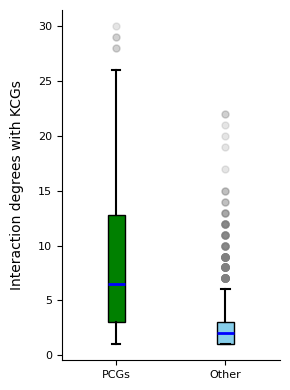

Box plot saved to results/gene_prediction/ggnet_ATTAG_degree_distributions_threshold0.85_epo200_32x4.png
Preparing data for KDE plot...
Generating KDE plot...
KDE plot saved to results/gene_prediction/ggnet_ATTAG_kde_plot_threshold0.85_epo200_32x4.png


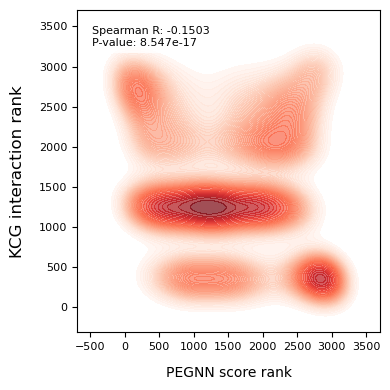

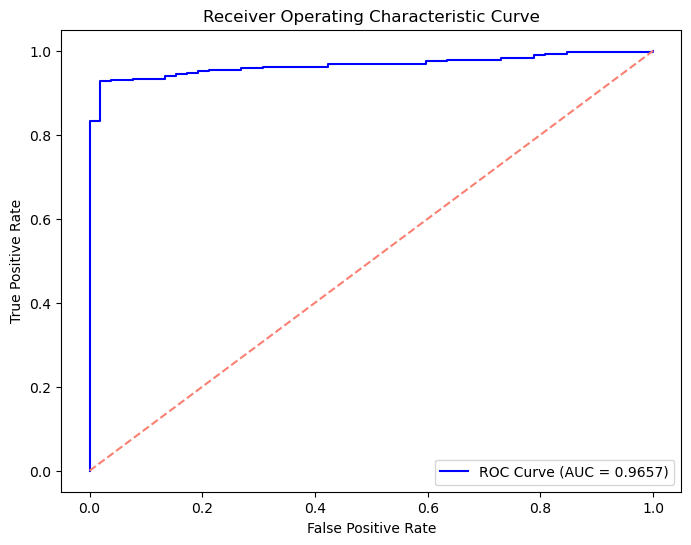

ROC Curve saved to results/gene_prediction/ggnet_ATTAG_threshold0.85_epo200_32x4_roc_curves.png


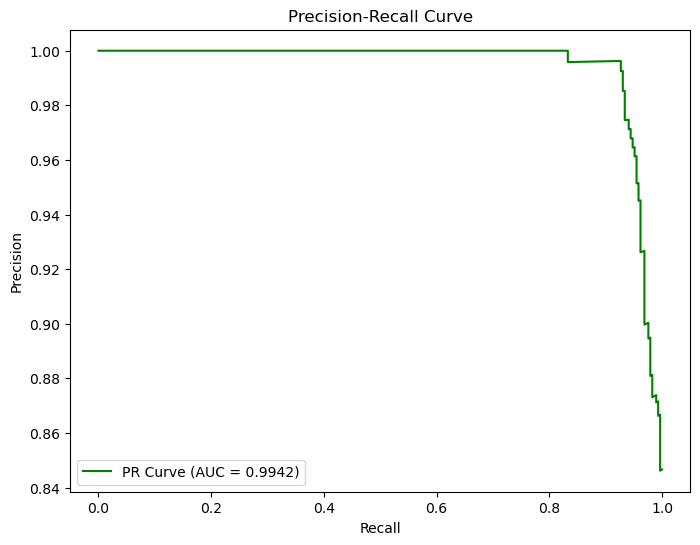

Precision-Recall Curve saved to results/gene_prediction/ggnet_ATTAG_threshold0.85_epo200_32x4_pr_curves.png
Predicted scores and labels saved to results/gene_prediction/ggnet_ATTAG_predicted_scores_threshold0.85_epo200.csv
Score distribution for label 1 saved to results/gene_prediction/ggnet_ATTAG_score_distribution_label1_threshold0.85_epo200.png
Score distribution for label 2 saved to results/gene_prediction/ggnet_ATTAG_score_distribution_label2_threshold0.85_epo200.png
Score distribution for label 0 saved to results/gene_prediction/ggnet_ATTAG_score_distribution_label0_threshold0.85_epo200.png
Score distribution for label 3 saved to results/gene_prediction/ggnet_ATTAG_score_distribution_label3_threshold0.85_epo200.png
Average scores and p-values saved to results/gene_prediction/ggnet_ATTAG_group_avg_scores_pvalues_threshold0.85_epo200.csv
Styled gene-group average score plot saved to results/gene_prediction/ggnet_ATTAG_gene_group_average_scores_styled_threshold0.85_epo200.png


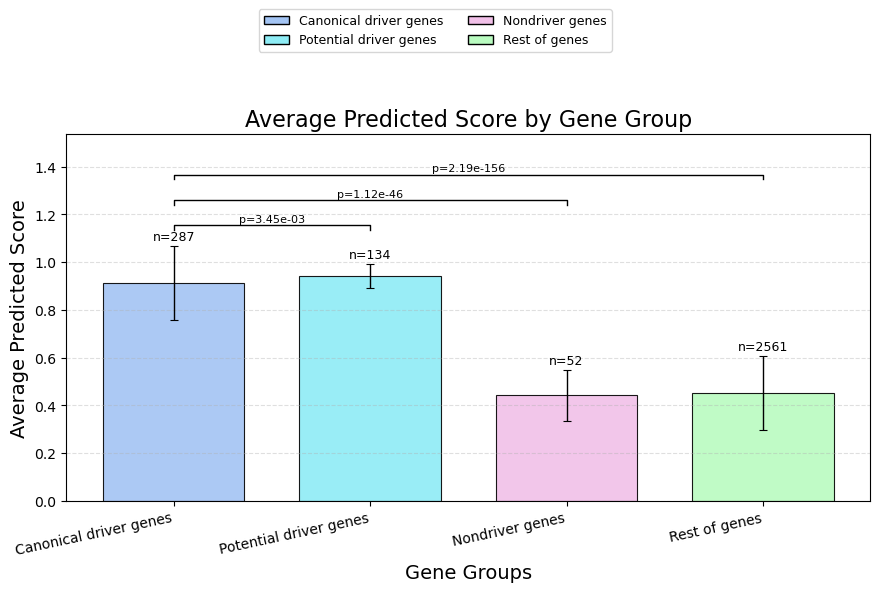

In [12]:
results = main(args)